## STEP 1: Import Libraries

Import all required libraries for the sales forecasting project.

This includes:

- **Data handling:** pandas, numpy  
- **Data visualization:** matplotlib, seaborn  
- **Machine learning models:** Linear Regression, Ridge Regression, Random Forest, Gradient Boosting, XGBoost  
- **Model selection & tuning:** train-test split, cross-validation, GridSearchCV  
- **Preprocessing:** LabelEncoder, StandardScaler  
- **Evaluation metrics:** RMSE, MAE, R² score  

These libraries provide all necessary tools for building and evaluating regression models for sales forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score

# Gradient Boosting (best for tabular/time data) 
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
print('All done to start👍')

All done to start👍


## STEP 2: Load and Inspect Dataset

Load the Walmart sales dataset and perform an initial inspection.

This step includes:
- Loading the dataset using `pandas`
- Checking dataset shape (rows and columns)
- Viewing the first few records
- Checking data types of each column

This helps understand the structure of the dataset before starting preprocessing and analysis.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv')

print(df.shape)       
print(df.head())
print(df.dtypes)

(6435, 8)
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


## STEP 3: Exploratory Data Analysis (EDA)

Perform exploratory data analysis to understand sales patterns, trends, and data structure.

This step includes:

- Converting the `Date` column into datetime format
- Generating basic statistical summary of numerical features
- Checking for missing values
- Visualizing sales distribution
- Analyzing monthly average sales trends over time
- Comparing average sales across different stores
- Comparing holiday vs non-holiday sales behavior

EDA helps in understanding seasonal trends, store performance, and the impact of holidays on sales.

             Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.578394      7.999151  
min      -2.060000     2.472000   126.064000      3.879000  
25%      47.460000     2.933000   131.735000      6.891000  
50%      62.670000     3.445000   182.616521      7.874

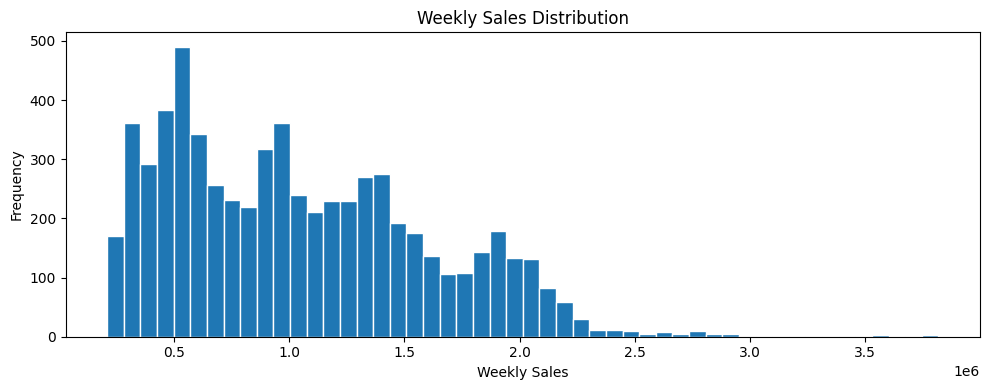

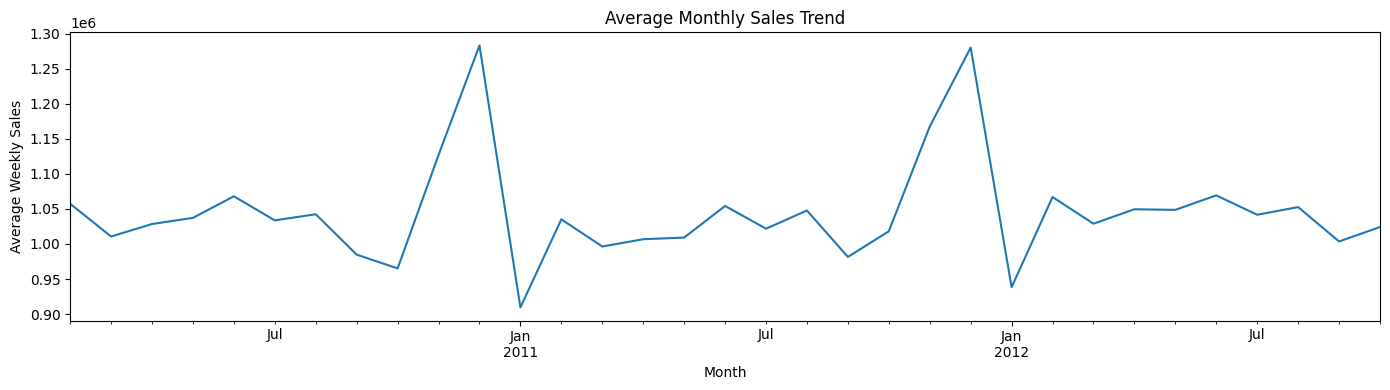

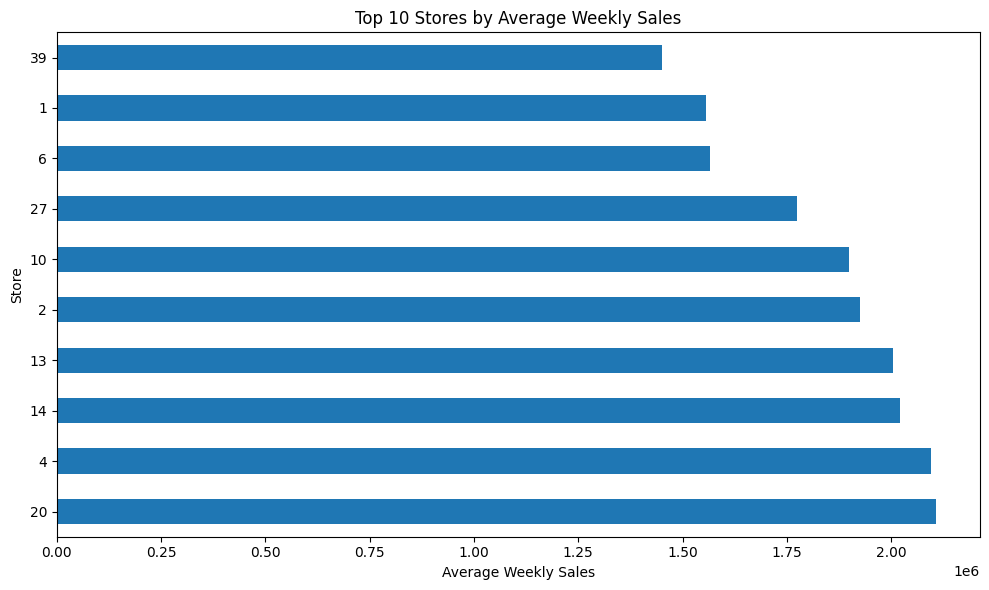

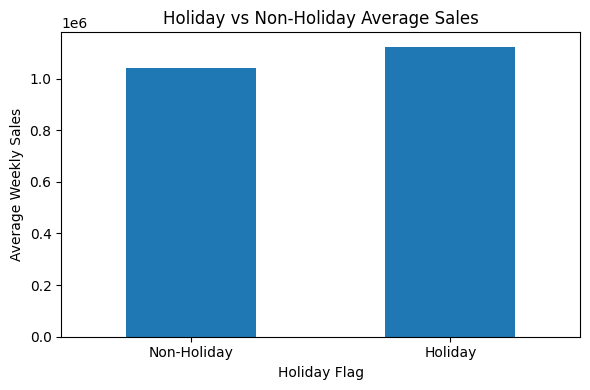

In [3]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Basic statistics
print(df.describe())

print("\nMissing values:\n")
print(df.isnull().sum())

# Sales distribution
plt.figure(figsize=(10,4))
plt.hist(df['Weekly_Sales'], bins=50, edgecolor='white')
plt.title('Weekly Sales Distribution')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Monthly average sales trend
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(14,4))
monthly_sales.plot()

plt.title('Average Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

# Average sales by store
top_stores = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top_stores.head(10).plot(kind='barh')

plt.title('Top 10 Stores by Average Weekly Sales')
plt.xlabel('Average Weekly Sales')
plt.ylabel('Store')
plt.tight_layout()
plt.show()

# Holiday vs Non-Holiday sales
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.figure(figsize=(6,4))
holiday_sales.plot(kind='bar')

plt.title('Holiday vs Non-Holiday Average Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Weekly Sales')
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.tight_layout()
plt.show()

## STEP 4: Data Preprocessing and Feature Engineering

Prepare the dataset for modeling by cleaning and creating useful time-based features.

This step includes:

- Converting the `Date` column to datetime format with error handling
- Sorting the dataset in chronological order
- Checking and handling missing values using forward fill method
- Creating new time-based features:
  - Year
  - Month
  - Week of the year

These features help the model capture seasonal patterns and time dependencies in sales data.

In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Sort data by time
df = df.sort_values('Date').reset_index(drop=True)

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing values (if any)
df = df.fillna(method='ffill')

# Feature engineering (time-based features)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# Final check
print("\nFinal dataset shape:", df.shape)
print(df.head())

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Month           0
dtype: int64

Final dataset shape: (6435, 11)
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1     10 2010-02-05    2193048.75             0        54.34       2.962   
2     37 2010-02-05     536006.73             0        45.97       2.572   
3     17 2010-02-05     789036.02             0        23.11       2.666   
4     30 2010-02-05     465108.52             0        39.05       2.572   

          CPI  Unemployment  Month  Year  Week  
0  211.096358         8.106      2  2010     5  
1  126.442065         9.765      2  2010     5  
2  209.852966         8.554      2  2010     5  
3  126.442065         6.548      2  2010     5  
4  210.752605         8.324      2  2010     5  


## STEP 5: Feature Engineering

Create time-based, lag, and rolling features to improve forecasting performance.

This step includes:

### Time-based features:
- Year
- Month
- Day
- Day of week
- Quarter
- Weekend indicator
- Week of year

### Lag features (past sales values):
- Sales from previous day (lag_1)
- Sales from 7 days ago (lag_7)
- Sales from 28 days ago (lag_28)

### Rolling statistics:
- 7-day moving average
- 28-day moving average
- 7-day rolling standard deviation

Finally, missing values created by lag and rolling operations are removed to prepare the dataset for modeling.

In [5]:
# Date-based features 
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Lag features (past sales)
df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_7'] = df['Weekly_Sales'].shift(7)
df['lag_28'] = df['Weekly_Sales'].shift(28)

# Rolling features
df['rolling_7_mean'] = df['Weekly_Sales'].shift(1).rolling(7).mean()
df['rolling_28_mean'] = df['Weekly_Sales'].shift(1).rolling(28).mean()
df['rolling_7_std'] = df['Weekly_Sales'].shift(1).rolling(7).std()

# Drop missing values created by lag features 
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Dataset shape after feature engineering:", df.shape)
print(df.columns.tolist())

Dataset shape after feature engineering: (6407, 22)
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Week', 'Day', 'DayOfWeek', 'Quarter', 'Is_Weekend', 'WeekOfYear', 'lag_1', 'lag_7', 'lag_28', 'rolling_7_mean', 'rolling_28_mean', 'rolling_7_std']


## STEP 6: Train-Test Split (Time Series)

Split the dataset into training and testing sets using a time-based approach.

Instead of random splitting, the last 90 days of data are used as the test set to preserve the time order, which is very important for time series forecasting.

This step includes:
- Creating a split date based on the last available date
- Separating data into training and testing sets
- Defining input features (X) and target variable (Weekly_Sales)

### Features used:
- Store information
- Economic indicators (Temperature, Fuel Price, CPI, Unemployment)
- Time-based features (Year, Month, Day, Week, etc.)
- Lag features (past sales values)
- Rolling statistics (moving averages and standard deviation)

In [6]:
# Time-based split (NEVER random for time series!) 
# Use last 90 days as test set

split_date = df['Date'].max() - pd.Timedelta(days=90)

train = df[df['Date'] <= split_date]
test  = df[df['Date'] >  split_date]

# Define features and target 
FEATURES = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter',
    'Is_Weekend', 'WeekOfYear',
    'lag_1', 'lag_7', 'lag_28',
    'rolling_7_mean', 'rolling_28_mean', 'rolling_7_std'
]

TARGET = 'Weekly_Sales'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 5822
Testing  samples : 585


## STEP 7: Model Training

Train multiple regression models to forecast weekly sales and compare their performance.

This step includes training the following models:

- **Linear Regression** (baseline model)
- **Random Forest Regressor** (handles non-linear relationships)
- **XGBoost Regressor** (advanced gradient boosting model for high accuracy)

### Model Details:
- Random Forest uses ensemble decision trees for better generalization
- XGBoost is configured with tuned hyperparameters for better forecasting performance
- Linear Regression is used as a simple baseline for comparison

After training, all models are fitted on the training dataset.## Step 7 — Train Models

In [7]:
# Model 1: Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)

# Model 2: Random Forest 
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Model 3: XGBoost 
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(X_train, y_train)

print("All models trained!")

All models trained!


## STEP 8: Model Predictions

Generate sales predictions using all trained models on the test dataset.

This step includes:
- Making predictions using Linear Regression, Random Forest, and XGBoost models
- Ensuring predicted sales values are non-negative (since sales cannot be negative)

### Post-processing:
Negative predictions are clipped to zero to maintain realistic sales values.

In [8]:
# Generate predictions from all models 
pred_lr  = lr.predict(X_test)
pred_rf  = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)

# Clip negatives (sales can't be negative) 
pred_lr  = np.clip(pred_lr, 0, None)
pred_rf  = np.clip(pred_rf, 0, None)
pred_xgb = np.clip(pred_xgb, 0, None)

## STEP 9: Model Evaluation

Evaluate the performance of all trained models using standard regression metrics.

This step includes:
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score (coefficient of determination)

### Purpose of metrics:
- **RMSE**: Penalizes large prediction errors more heavily
- **MAE**: Measures average prediction error
- **R² Score**: Shows how well the model explains variance in sales data

Each model (Linear Regression, Random Forest, and XGBoost) is evaluated on the test dataset to compare performance.

In [9]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

evaluate("Linear Regression", y_test, pred_lr)
evaluate("Random Forest",     y_test, pred_rf)
evaluate("XGBoost",           y_test, pred_xgb)


  Linear Regression
  RMSE : 495452.8246
  MAE  : 416035.0195
  R²   : 0.1187

  Random Forest
  RMSE : 129824.1900
  MAE  : 71901.3166
  R²   : 0.9395

  XGBoost
  RMSE : 71940.5520
  MAE  : 52565.1679
  R²   : 0.9814


## STEP 10: Visualization of Results

Visualize model performance by comparing actual sales with predicted values and analyzing feature importance.

This step includes:

### 1. Actual vs Predicted Sales Plot
- Compares real sales with predictions from all models
- Helps visually evaluate how closely each model follows actual trends over time

### 2. Feature Importance (XGBoost)
- Displays the most important features influencing sales prediction
- Helps understand which factors (lags, rolling averages, store info, etc.) impact sales the most

XGBoost feature importance provides business insights into demand drivers and seasonal patterns.

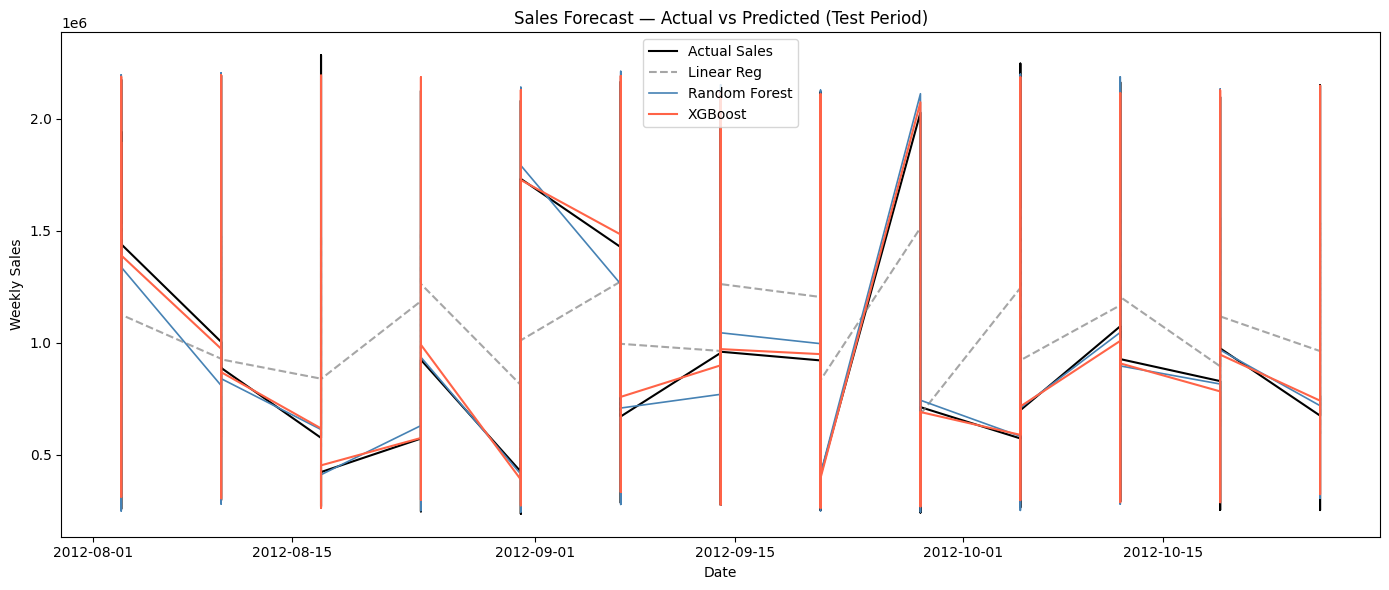

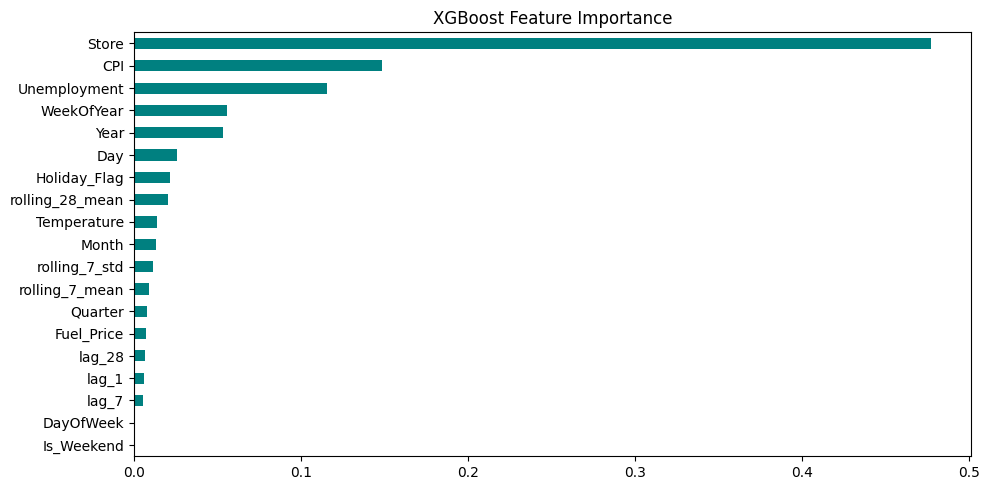

In [10]:
plt.figure(figsize=(14, 6))

test_dates = test['Date'].values

plt.plot(test_dates, y_test.values,  label='Actual Sales',    color='black',    linewidth=1.5)
plt.plot(test_dates, pred_lr,        label='Linear Reg',      color='gray',     linestyle='--', alpha=0.7)
plt.plot(test_dates, pred_rf,        label='Random Forest',   color='steelblue',linewidth=1.2)
plt.plot(test_dates, pred_xgb,       label='XGBoost',         color='tomato',   linewidth=1.5)

plt.title('Sales Forecast — Actual vs Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance (XGBoost) 
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## STEP 11: Hyperparameter Tuning

Improve model performance by tuning the XGBoost model using Grid Search with Time Series Cross-Validation.

This step includes:

- Defining a parameter grid for XGBoost hyperparameters:
  - Number of estimators
  - Maximum tree depth
  - Learning rate
  - Subsample ratio
  - Column sampling ratio

- Using **TimeSeriesSplit** to ensure proper validation for time-dependent data
- Applying **GridSearchCV** to find the best combination of hyperparameters
- Retraining the model using the best parameters
- Evaluating the tuned model using RMSE

### Key Point:
TimeSeriesSplit is used instead of random CV to avoid data leakage in time series forecasting problems.

In [11]:
# GridSearch on XGBoost 
param_grid = {
    'n_estimators'    : [300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best RMSE     :", -grid_search.best_score_)

# Retrain with best params 
best_xgb = grid_search.best_estimator_

pred_best = np.clip(best_xgb.predict(X_test), 0, None)

evaluate("Tuned XGBoost", y_test, pred_best)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.9}
Best RMSE     : 196619.57275890023

  Tuned XGBoost
  RMSE : 74147.6224
  MAE  : 55338.2906
  R²   : 0.9803


## STEP 12: Future Sales Forecasting

Generate future sales predictions for the next 30 days using the trained XGBoost model.

This step includes:

- Creating a future date range for the next 30 days
- Building a future dataset with required time-based features
- Filling lag features using the most recent available sales data
- Using last known values for external factors (Store, Temperature, Fuel Price, CPI, etc.)
- Predicting future sales using the trained model
- Visualizing historical sales vs forecasted sales

### Key Idea:
Since future actual values are not available, lag and rolling features are approximated using recent historical data.

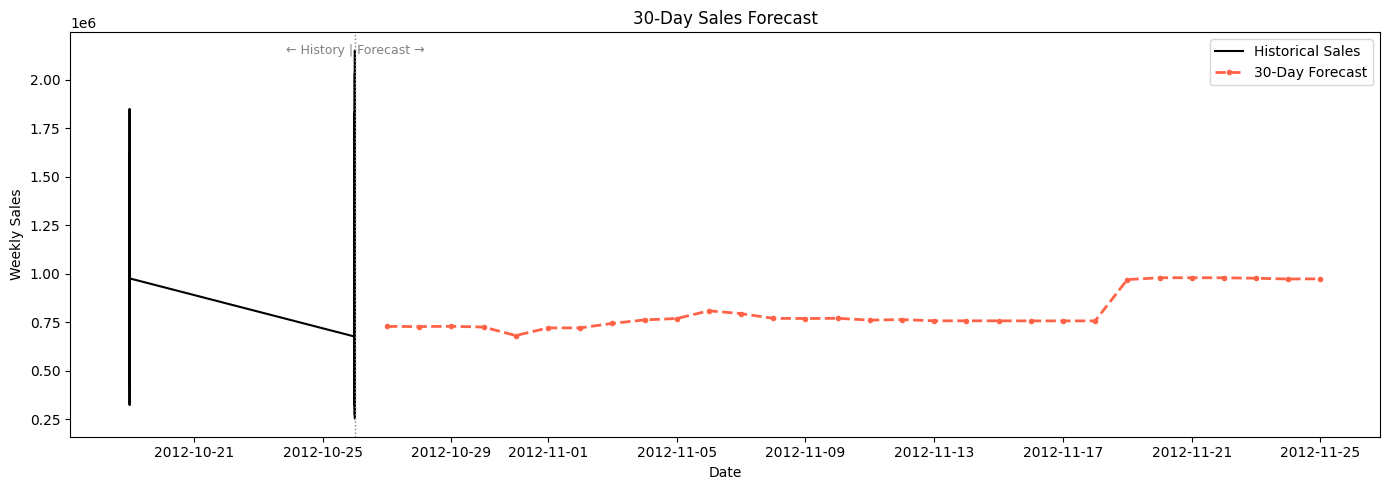


Forecast values:
  2012-10-27 → 727907.44
  2012-10-28 → 726875.25
  2012-10-29 → 728469.44
  2012-10-30 → 724502.50
  2012-10-31 → 680776.31
  2012-11-01 → 719986.75
  2012-11-02 → 720231.81
  2012-11-03 → 743398.69
  2012-11-04 → 761378.75
  2012-11-05 → 768584.44
  2012-11-06 → 808388.31
  2012-11-07 → 793796.75
  2012-11-08 → 769356.19
  2012-11-09 → 768589.12
  2012-11-10 → 769599.50
  2012-11-11 → 760264.19
  2012-11-12 → 763005.38
  2012-11-13 → 756616.31
  2012-11-14 → 756616.31
  2012-11-15 → 756616.31
  2012-11-16 → 756332.75
  2012-11-17 → 756236.75
  2012-11-18 → 756236.75
  2012-11-19 → 969463.25
  2012-11-20 → 978781.25
  2012-11-21 → 978781.25
  2012-11-22 → 978598.12
  2012-11-23 → 976223.44
  2012-11-24 → 972293.62
  2012-11-25 → 973249.50


In [12]:
# Create future date range (next 30 days)
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Build a simple future feature frame 
future_df = pd.DataFrame({'Date': future_dates})

future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = future_df['Date'].dt.day
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek
future_df['Quarter'] = future_df['Date'].dt.quarter
future_df['Is_Weekend'] = (future_df['DayOfWeek'] >= 5).astype(int)
future_df['WeekOfYear'] = future_df['Date'].dt.isocalendar().week.astype(int)

# Fill lags with last known values 
recent_sales = df['Weekly_Sales'].iloc[-28:].values

future_df['lag_1'] = recent_sales[-1]
future_df['lag_7'] = recent_sales[-7]
future_df['lag_28'] = recent_sales[-28]

future_df['rolling_7_mean'] = recent_sales[-7:].mean()
future_df['rolling_28_mean'] = recent_sales.mean()
future_df['rolling_7_std'] = recent_sales[-7:].std()

# Use most recent known values for other features 
future_df['Store'] = df['Store'].iloc[-1]
future_df['Holiday_Flag'] = 0
future_df['Temperature'] = df['Temperature'].iloc[-1]
future_df['Fuel_Price'] = df['Fuel_Price'].iloc[-1]
future_df['CPI'] = df['CPI'].iloc[-1]
future_df['Unemployment'] = df['Unemployment'].iloc[-1]

#  Predict 
future_preds = np.clip(best_xgb.predict(future_df[FEATURES]), 0, None)

# Plot forecast 
plt.figure(figsize=(14, 5))

hist = df.tail(60)
plt.plot(hist['Date'], hist['Weekly_Sales'], label='Historical Sales', color='black', linewidth=1.5)
plt.plot(future_dates, future_preds, label='30-Day Forecast', color='tomato',
         linewidth=2, linestyle='--', marker='o', markersize=3)

plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1)
plt.text(last_date, plt.ylim()[1]*0.95, '← History | Forecast →',
         ha='center', fontsize=9, color='gray')

plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

print("\nForecast values:")
for date, val in zip(future_dates, future_preds):
    print(f"  {date.date()} → {val:.2f}")